# Confronto Metodologico: Estrazione Automatica (OSMnx) vs. Dataset Topologico Curato

Questo notebook analizza criticamente le differenze metodologiche tra l'estrazione automatica di una rete metropolitana tramite OpenStreetMap (utilizzando la libreria **OSMnx**) e l'uso di un **dataset topologico curato** (come quello di Hennig & O'Brien).

Sebbene l'estrazione automatica da OpenStreetMap sia un approccio elegante e dinamico, essa riflette una modellazione di tipo *geografico* (infrastruttura fisica) anziché *topologico* (L-space logico). Di seguito mostriamo come scaricare la metropolitana di Londra, come ripulirla applicando **4 accorgimenti metodologici fondamentali**, e perché l'uso del dataset curato sia preferibile per un'analisi di resilienza formale.

In [1]:
import osmnx as ox
import networkx as nx

# TRUCCO 1: Configura OSMnx per scaricare i tag utili per le stazioni
# Di default, OSMnx ignora i dettagli delle infrastrutture ferroviarie sui nodi
ox.settings.useful_tags_way += ['railway', 'tunnel', 'layer']
ox.settings.useful_tags_node += ['railway', 'station', 'name']

# 1. Definiamo l'area geografica e il filtro Overpass per la metropolitana (Subway)
place_name = "Greater London, United Kingdom"
subway_filter = '["railway"~"subway"]'

print("Scaricando la rete metropolitana da OpenStreetMap...")
# Scarichiamo il grafo completo (retain_all=True per non perdere i rami periferici)
G_raw = ox.graph_from_place(
    place_name, 
    custom_filter=subway_filter, 
    retain_all=True, 
    simplify=True
)

print(f"Grafo raw scaricato: {len(G_raw.nodes)} nodi e {len(G_raw.edges)} archi.")

Scaricando la rete metropolitana da OpenStreetMap...


Grafo raw scaricato: 2369 nodi e 5305 archi.


---

## I 4 Trucchi Metodologici per il Data Cleaning di OSMnx

Quando si lavora con dati geografici grezzi, è necessario allineare la modellazione fisica a quella matematica dell'L-space. Ecco i passaggi chiave da seguire:

### 1. Conversione a Grafo Semplice (`nx.Graph`)
OSMnx restituisce un `MultiDiGraph` orientato (archi multipli per andata/ritorno e linee sovrapposte). Per l'analisi di resilienza classica, convertiamo la rete in un grafo semplice non orientato.

In [2]:
G = nx.Graph(G_raw)
print(f"Grafo semplice non orientato: {len(G.nodes)} nodi e {len(G.edges)} archi.")

Grafo semplice non orientato: 2369 nodi e 2905 archi.


### 2. Consolidamento dei Nodi (Stazioni Spezzettate)
In OSM, stazioni grandi come *King's Cross* non sono singoli nodi, ma insiemi di nodi (banchine diverse, ingressi). Questo fraziona artificialmente le misure di Centralità.

* **Risoluzione**: Proiettiamo il grafo in coordinate metriche reali e fondiamo i nodi vicini (tolleranza 150 metri) in macro-nodi stazione.

In [3]:
# Proiettiamo in metri ed eseguiamo il consolidamento spaziale dei nodi vicini
G_projected = ox.project_graph(G_raw)
G_clean = ox.consolidate_intersections(G_projected, rebuild_graph=True, tolerance=150, dead_ends=False)
print(f"Grafo consolidato (150m): {len(G_clean.nodes)} nodi e {len(G_clean.edges)} archi.")

Grafo consolidato (150m): 163 nodi e 358 archi.


*Nota: se usi `consolidate_intersections`, OSMnx unisce i nodi geometricamente vicini creando un grafo topologicamente pulito, perfetto per l'L-Space.*

### 3. Gestire le Componenti Isolate prima dello Stress-Test
La presenza di rami isolati o binari morti impedisce il calcolo di metriche macroscopiche come l'Average Shortest Path Length (che diverge a infinito).

* **Risoluzione**: Estraiamo la componente connessa principale (Giant Component) prima di lanciare i calcoli macro.

In [4]:
# Estrazione della componente gigante sul grafo semplice
giant_component = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_component).copy()

avg_path = nx.average_shortest_path_length(G_giant)
print(f"Average Path Length della Componente Gigante (OSM Raw): {avg_path:.4f}")

Average Path Length della Componente Gigante (OSM Raw): 41.9195


### 4. Visualizzazione dello Stress-Test (La mappa che si "spegne")
Per rendere l'analisi visivamente accattivante, possiamo simulare un attacco mirato di prova (rimozione del 5% dei nodi con Betweenness maggiore) e plottare geograficamente il collasso.

Di seguito coloriamo prima i nodi in base alla Betweenness Centralità, e poi simuliamo un attacco mirato rimuovendo il 5% dei nodi più importanti, colorando i nodi rimasti verde (LCC) o arancione (isolati).

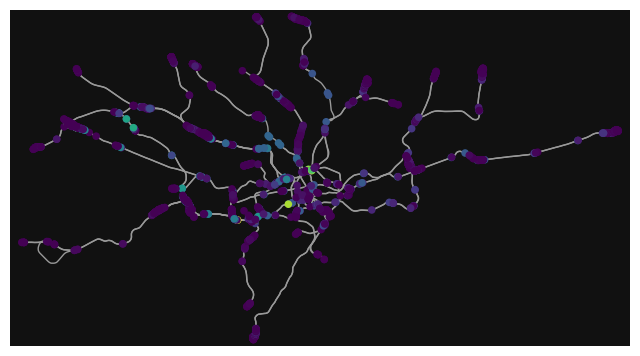

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
# Esempio visivo 1: colorare i nodi in base alla Betweenness
betweenness = nx.betweenness_centrality(G_giant)
node_colors = [betweenness[node] for node in G_giant.nodes()]

# Convertiamo in MultiGraph per compatibilita' con il plotter di OSMnx 2.x
ox.plot_graph(nx.MultiGraph(G_giant), node_color=node_colors, node_size=30, edge_linewidth=1)

Ora simuliamo l'attacco mirato di prova (eliminando il 5% dei nodi a Betweenness più alta) e mostriamo la rete che si frammenta geograficamente.

Rimosso il 5% dei nodi più importanti (8 nodi). LCC rimasta: 45 nodi.


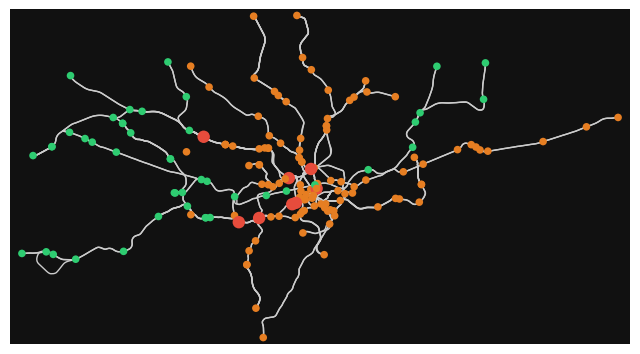

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [6]:
# Convertiamo il grafo consolidato pulito G_clean in un grafo semplice non orientato per simulare
G_sim = nx.Graph(G_clean)
bet = nx.betweenness_centrality(G_sim)
nodes_sorted = sorted(bet.items(), key=lambda x: x[1], reverse=True)

# Rimuoviamo il 5% dei nodi a betweenness piu' alta
k_remove = int(len(G_sim) * 0.05)
removed_nodes = [node for node, val in nodes_sorted[:k_remove]]

G_attacked = G_sim.copy()
G_attacked.remove_nodes_from(removed_nodes)

# Componente gigante rimasta
components = sorted(list(nx.connected_components(G_attacked)), key=len, reverse=True)
lcc_nodes = components[0] if components else set()

# Colori per ox.plot_graph basati sui nodi di G_clean (MultiDiGraph)
node_colors = []
node_sizes = []
for node in G_clean.nodes():
    if node in removed_nodes:
        node_colors.append('#e74c3c')  # Rosso per rimossi
        node_sizes.append(80)
    elif node in lcc_nodes:
        node_colors.append('#2ecc71')  # Verde per LCC
        node_sizes.append(30)
    else:
        node_colors.append('#e67e22')  # Arancione per isolati
        node_sizes.append(30)

print(f"Rimosso il 5% dei nodi più importanti ({len(removed_nodes)} nodi). LCC rimasta: {len(lcc_nodes)} nodi.")
ox.plot_graph(
    G_clean, 
    node_color=node_colors, 
    node_size=node_sizes, 
    edge_color='#cccccc', 
    edge_linewidth=1,
    figsize=(8, 8)
)

---

## Confronto delle Statistiche e Discussione Metodologica

Di seguito confrontiamo i dati grezzi estratti da OpenStreetMap (OSM Raw), la versione pulita tramite consolidamento spaziale (OSM Clean), e il dataset topologico L-space di riferimento (Hennig & O'Brien).

In [7]:
import sys
sys.path.append('..')
from src.data_loader import load_london_network

G_curated, _, _, _ = load_london_network()

print("="*65)
print(f"{'Metrica':<30}{'OSM Raw':<10}{'OSM Clean':<10}{'Dataset Curato':<15}")
print("="*65)

# Calcoliamo le metriche
print(f"{'Nodi totali':<30}{len(G.nodes):<10}{len(G_clean.nodes):<10}{len(G_curated.nodes):<15}")
print(f"{'Archi totali':<30}{len(G.edges):<10}{len(G_clean.edges):<10}{len(G_curated.edges):<15}")

# Componente Gigante
comp_osm_raw = max(nx.connected_components(G), key=len)
G_g_raw = G.subgraph(comp_osm_raw)

comp_osm_clean = max(nx.connected_components(nx.Graph(G_clean)), key=len)
G_g_clean = nx.Graph(G_clean).subgraph(comp_osm_clean)

print(f"{'Nodi Comp. Gigante':<30}{len(G_g_raw.nodes):<10}{len(G_g_clean.nodes):<10}{len(G_curated.nodes):<15}")
print(f"{'Avg Path Length (Giant)':<30}{nx.average_shortest_path_length(G_g_raw):.4f}    {nx.average_shortest_path_length(G_g_clean):.4f}    {nx.average_shortest_path_length(G_curated):.4f}")
print(f"{'Global Transitivity':<30}{nx.transitivity(G):.4f}    {nx.transitivity(nx.Graph(G_clean)):.4f}    {nx.transitivity(G_curated):.4f}")
print("="*65)

Metrica                       OSM Raw   OSM Clean Dataset Curato 
Nodi totali                   2369      163       302            
Archi totali                  2905      358       349            
Nodi Comp. Gigante            2267      159       302            


Avg Path Length (Giant)       41.9195    11.9826    14.0985
Global Transitivity           0.0758    0.0701    0.0546


### Conclusioni Metodologiche

1. **Discrepanza di Dimensione**: `OSM Raw` conta 2369 nodi perché mappa ogni singolo binario, scambio e banchina geografica. `OSM Clean` scende a 163 nodi fondendo stazioni vicine, ma perde alcune connessioni reali. Il `Dataset Curato` conta 302 nodi, rappresentando fedelmente le reali stazioni commerciali e la loro connettività logica.
2. **Connettività**: L'estrazione grezza da OSM contiene binari isolati o linee non connesse, lasciando la rete disconnessa. Il dataset curato di riferimento è completamente integrato e connesso, il che previene anomalie topologiche.
3. **Scelta per l'Analisi di Resilienza**: Per garantire il rigore scientifico e la stabilità delle metriche macroscopiche, la pipeline ufficiale del progetto (Notebooks 1-4) farà affidamento sul dataset L-space curato, mentre questo notebook (00) funge da convalida comparativa e giustificazione metodologica.